# Fine-Tuning: Lector de Dígitos OCR

Notebook para el fine-tuning del módulo de reconocimiento de PaddleOCR sobre crops de odómetros de medidores de agua.

## Dataset

- **Fuente**: `data/ocr/` (construido por `scripts/data/build_ocr.py`)
- **Crops**: 1,199 (rotados + LAB masked, labels enteros solamente)
- **Split estratificado**: 959 train / 120 val / 120 test (80/10/10)
- **Formato labels**: PaddleOCR (`images/{split}/{name}\t{integer_label}`)

## Contexto

Las iteraciones de Fase 1 (preprocessing) se ejecutaron en `04_eval_ocr.ipynb` con modelos pretrained.
El baseline e iteraciones 1–3 de Fase 2 también se evalúan ahí.

**Iteraciones de fine-tuning documentadas en este notebook:**
- **Iter 4 (Domain Adaptation):** Fine-tune de `en_PP-OCRv4_mobile_rec` (ganador de iter3) con diccionario digit-only sobre crops sin padding.
- **Iter 5 (OBB Crop Padding):** Regenerar crops con 5 px de padding (`OBB_CROP_PADDING=5`) + reentrenar fine-tuning con misma configuración de Iter 4.
- **Iter 6 (Máscara LAB mejorada):** Reentrenar `en_PP-OCRv4_mobile_rec` sobre `data/ocr/` regenerado con la máscara LAB actualizada.

## Workflow

1. Preparar dataset en formato PaddleOCR; si cambia el masking, regenerar `data/ocr/` primero
2. Crear diccionario custom (solo dígitos 0–9)
3. Fine-tune `en_PP-OCRv4_mobile_rec` con pesos pretrained
4. Exportar modelo a formato de inferencia
5. Evaluar con las mismas métricas de `04_eval_ocr.ipynb`
6. Comparar con iteraciones anteriores

---

## PARTE 1: CONFIGURACIÓN DEL ENTORNO

### 1.1 Verificar GPU disponible

Fine-tuning requiere GPU. Se espera una Tesla T4 (Google Colab).

In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("ADVERTENCIA: No hay GPU disponible. Fine-tuning será extremadamente lento.")

PyTorch version: 2.10.0+cu128
CUDA disponible: True
GPU: Tesla T4
VRAM: 14.6 GB


### 1.2 Instalar dependencias

In [2]:
import os, subprocess
os.environ['PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK'] = 'True'

# Detect CUDA version for correct paddlepaddle-gpu index
cuda_version = subprocess.check_output(
    "nvcc --version | grep -oP 'release \\K[0-9]+'", shell=True
).decode().strip()
cuda_tag = {'11': 'cu118', '12': 'cu126'}.get(cuda_version, 'cu126')
print(f"CUDA major version: {cuda_version} -> using {cuda_tag} index")

# --no-deps avoids re-downloading ~1.2 GB of NVIDIA CUDA libs that Colab
# already ships.  --trusted-host bypasses the expired SSL certificate on the
# PaddlePaddle mirror (v3.2.0 is not on PyPI, only on their own index).
get_ipython().system(
    f'pip install -q paddlepaddle-gpu==3.2.0 --no-deps'
    f' --trusted-host www.paddlepaddle.org.cn'
    f' -i https://www.paddlepaddle.org.cn/packages/stable/{cuda_tag}/'
)
get_ipython().system('pip install -q paddleocr editdistance rapidfuzz pyyaml lmdb')
get_ipython().system('pip uninstall -y langchain langchain-community 2>/dev/null')

import paddle
print(f"PaddlePaddle version: {paddle.__version__}")
print(f"CUDA disponible (Paddle): {paddle.device.is_compiled_with_cuda()}")

CUDA major version: 12 -> using cu126 index
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 GB 581.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.9/325.9 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 4.6 MB/s eta 0:00:00
   ━━

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


PaddlePaddle version: 3.2.0
CUDA disponible (Paddle): True


### 1.3 Montar Google Drive

**IMPORTANTE:** Antes de ejecutar esta celda, sube `data/ocr/` y `data/annotations/` a tu Google Drive.

La estructura esperada en Drive es:
```
water-meter-training/
  data/
    ocr/
      images/{train,val,test}/
      train.txt, val.txt, test.txt
    annotations/
      metadata.csv
      ocr-labels.csv
      ocr-crops/
  ocr-reader/
    export/          ← modelo + artefactos por iteración
```

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

DRIVE_MOUNT_PATH = '/content/drive/MyDrive/water-meter-training'
assert os.path.exists(DRIVE_MOUNT_PATH), (
    f"No se encontró {DRIVE_MOUNT_PATH}. "
    "Verifica que la carpeta water-meter-training existe en tu Drive."
)
print(f"Drive montado: {DRIVE_MOUNT_PATH}")

Mounted at /content/drive
Drive montado: /content/drive/MyDrive/water-meter-training


### 1.4 Configuración de Rutas del Proyecto

In [4]:
# =====================================================
# CONFIGURACION DE RUTAS
# =====================================================

DRIVE_BASE = '/content/drive/MyDrive/water-meter-training'

# Dataset fuente (construido por scripts/data/build_ocr.py)
SOURCE_OCR_PATH = f'{DRIVE_BASE}/data/ocr'

# Annotations (metadata + raw crops para comparacion)
SOURCE_ANNOTATIONS = f'{DRIVE_BASE}/data/annotations'

# Componente: ocr-reader
COMPONENT_DIR = f'{DRIVE_BASE}/ocr-reader'
EXPORT_DIR = f'{COMPONENT_DIR}/export'

# Workspace local para entrenamiento (rapido, efimero)
WORKSPACE = '/content/ocr-finetune'
DATASET_PATH = f'{WORKSPACE}/dataset'
PADDLEOCR_DIR = f'{WORKSPACE}/PaddleOCR'
OUTPUT_DIR = f'{WORKSPACE}/output'

# =====================================================
# Rutas derivadas (no modificar)
# =====================================================
LABEL_FILES = {s: f'{DATASET_PATH}/{s}.txt' for s in ['train', 'val', 'test']}
SPLIT_IMAGE_DIRS = {s: f'{DATASET_PATH}/images/{s}' for s in ['train', 'val', 'test']}
METADATA_CSV = f'{SOURCE_ANNOTATIONS}/metadata.csv'
OCR_LABELS_CSV = f'{SOURCE_ANNOTATIONS}/ocr-labels.csv'
RAW_CROPS_DIR = f'{SOURCE_ANNOTATIONS}/ocr-crops'

# Crear directorios
os.makedirs(WORKSPACE, exist_ok=True)
os.makedirs(COMPONENT_DIR, exist_ok=True)

print("=== CONFIGURACION DE RUTAS ===")
print(f"Dataset fuente:    {SOURCE_OCR_PATH}")
print(f"Annotations:       {SOURCE_ANNOTATIONS}")
print(f"Componente:        {COMPONENT_DIR}")
print(f"  export/          {EXPORT_DIR}")
print(f"Workspace local:   {WORKSPACE}")
print(f"  dataset/         {DATASET_PATH}")
print(f"  PaddleOCR/       {PADDLEOCR_DIR}")
print(f"  output/          {OUTPUT_DIR}")

=== CONFIGURACION DE RUTAS ===
Dataset fuente:    /content/drive/MyDrive/water-meter-training/data/ocr
Annotations:       /content/drive/MyDrive/water-meter-training/data/annotations
Componente:        /content/drive/MyDrive/water-meter-training/ocr-reader
  export/          /content/drive/MyDrive/water-meter-training/ocr-reader/export
Workspace local:   /content/ocr-finetune
  dataset/         /content/ocr-finetune/dataset
  PaddleOCR/       /content/ocr-finetune/PaddleOCR
  output/          /content/ocr-finetune/output


### 1.5 Importar bibliotecas necesarias

In [5]:
import csv
import os
import random
import re
import shutil
import subprocess
import time
from pathlib import Path
from datetime import datetime
from collections import Counter

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import editdistance
from paddleocr import PaddleOCR

# Fijar semilla para reproducibilidad
random.seed(42)
np.random.seed(42)

print("Bibliotecas importadas correctamente")

Connectivity check to the model hoster has been skipped because `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` is enabled.


Bibliotecas importadas correctamente


---

## PARTE 2: PREPARACIÓN DEL DATASET

### 2.1 Copiar Dataset a Workspace

Copia `data/ocr/` desde Drive al workspace local para velocidad de I/O durante entrenamiento.

In [6]:
# Copiar dataset a workspace (si no existe ya)
needs_copy = not os.path.exists(DATASET_PATH) or not os.path.exists(LABEL_FILES['val'])

# Verificar que las imagenes fuente existen
source_check = os.path.exists(f'{SOURCE_OCR_PATH}/images/train')
assert source_check, f"No se encontro {SOURCE_OCR_PATH}/images/train. Verifica la estructura en Drive."

if needs_copy:
    print(f"Copiando dataset desde Drive a workspace local...")
    if os.path.exists(DATASET_PATH):
        shutil.rmtree(DATASET_PATH)
    shutil.copytree(SOURCE_OCR_PATH, DATASET_PATH)
    print(f"Copiado: {SOURCE_OCR_PATH} -> {DATASET_PATH}")
else:
    print(f"Dataset ya existe en workspace local: {DATASET_PATH}")

# Verificar conteos
for split in ['train', 'val', 'test']:
    n_imgs = len(os.listdir(SPLIT_IMAGE_DIRS[split]))
    with open(LABEL_FILES[split]) as f:
        n_labels = sum(1 for line in f if line.strip())
    print(f"  {split}: {n_imgs} imagenes, {n_labels} labels")
    assert n_imgs == n_labels, f"Mismatch en {split}: {n_imgs} imgs vs {n_labels} labels"

Copiando dataset desde Drive a workspace local...
Copiado: /content/drive/MyDrive/water-meter-training/data/ocr -> /content/ocr-finetune/dataset
  train: 959 imagenes, 959 labels
  val: 120 imagenes, 120 labels
  test: 120 imagenes, 120 labels


### 2.2 Cargar Labels y Metadata

In [7]:
def load_split_labels(split_file):
    """Carga archivo de labels PaddleOCR -> DataFrame."""
    entries = []
    with open(split_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t')
            img_path = parts[0]  # e.g. "images/val/00002.jpg"
            label = parts[1]
            filename = os.path.basename(img_path)
            entries.append({'filename': filename, 'label': label, 'rel_path': img_path})
    return pd.DataFrame(entries)


def load_metadata(metadata_path):
    """Carga metadata.csv -> DataFrame con info de has_decimal por imagen."""
    df = pd.read_csv(metadata_path)
    df['has_decimal'] = df['has_decimal'].apply(lambda x: str(x).strip() == 'True')
    return df[['image', 'has_decimal', 'background', 'n_digits', 'group', 'split']]


# Cargar labels de val y test
val_df = load_split_labels(LABEL_FILES['val'])
test_df = load_split_labels(LABEL_FILES['test'])

# Cargar metadata y hacer join
meta_df = load_metadata(METADATA_CSV)
meta_df = meta_df.rename(columns={'image': 'filename'})

val_df = val_df.merge(meta_df[['filename', 'has_decimal', 'background', 'n_digits']], on='filename', how='left')
test_df = test_df.merge(meta_df[['filename', 'has_decimal', 'background', 'n_digits']], on='filename', how='left')

print(f"Val set:  {len(val_df)} imagenes "
      f"({val_df['has_decimal'].sum()} con_decimal, "
      f"{(~val_df['has_decimal']).sum()} sin_decimal)")
print(f"Test set: {len(test_df)} imagenes "
      f"({test_df['has_decimal'].sum()} con_decimal, "
      f"{(~test_df['has_decimal']).sum()} sin_decimal)")

Val set:  120 imagenes (84 con_decimal, 36 sin_decimal)
Test set: 120 imagenes (84 con_decimal, 36 sin_decimal)


### 2.3 Preparar Dataset para PaddleOCR Training

PaddleOCR `tools/train.py` espera:
- Un directorio `data_dir` con las imágenes
- Label files con formato `<ruta_relativa>\t<label>` (relativas a `data_dir`)

Nuestro dataset ya tiene este formato. Solo necesitamos crear el diccionario custom.

In [8]:
# Crear diccionario custom: solo digitos 0-9
# Esto reduce el espacio de salida de ~438 caracteres a 10,
# forzando al modelo a reconocer solo digitos.
DICT_PATH = f'{WORKSPACE}/digit_dict.txt'

with open(DICT_PATH, 'w') as f:
    for d in range(10):
        f.write(f'{d}\n')

print(f"Diccionario creado: {DICT_PATH}")
with open(DICT_PATH) as f:
    print(f"  Caracteres: {[line.strip() for line in f]}")

# Verificar que todos los labels solo contienen digitos
non_digit_re = re.compile(r'[^0-9]')
for split in ['train', 'val', 'test']:
    with open(LABEL_FILES[split]) as f:
        for i, line in enumerate(f):
            parts = line.strip().split('\t')
            if len(parts) >= 2:
                label = parts[1]
                if non_digit_re.search(label):
                    print(f"  ADVERTENCIA: {split} linea {i}: label no numerico '{label}'")

print("Validacion de labels completada (solo digitos 0-9 esperados)")

Diccionario creado: /content/ocr-finetune/digit_dict.txt
  Caracteres: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Validacion de labels completada (solo digitos 0-9 esperados)


### 2.4 Visualizar Muestras del Dataset

Crops procesados (rotados + masked) tal como los verá el modelo durante fine-tuning.

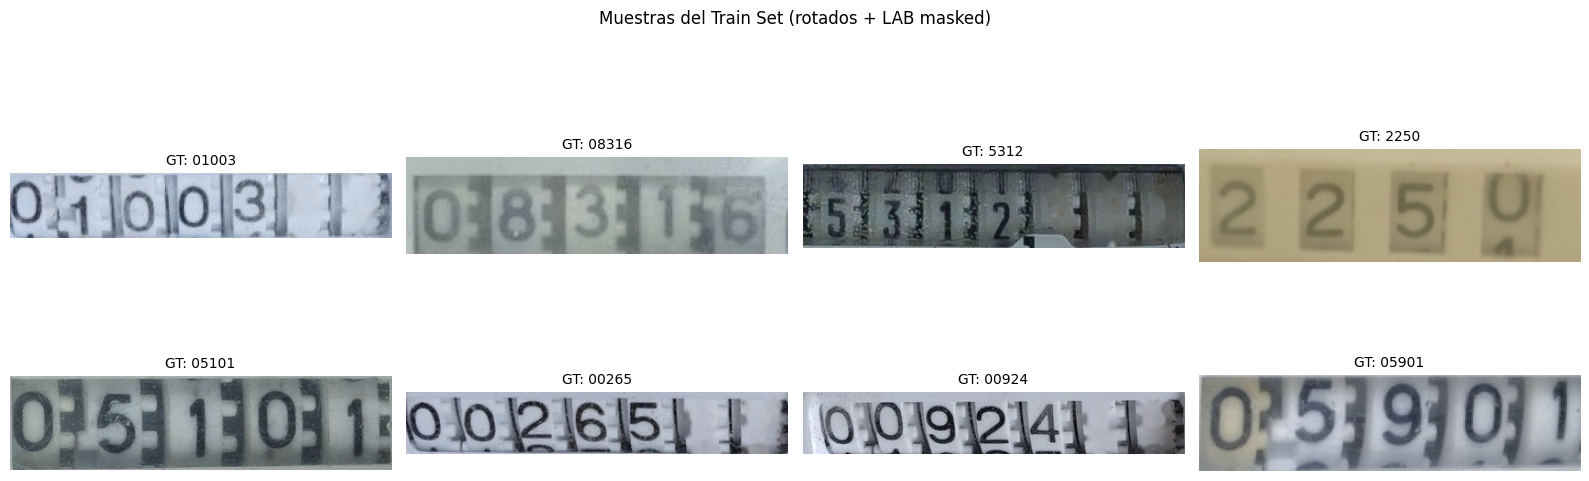

In [9]:
import random

# Mostrar 8 crops aleatorios del train set
train_df = load_split_labels(LABEL_FILES['train'])
sample_train = train_df.sample(n=min(8, len(train_df)), random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for idx, (_, row) in enumerate(sample_train.iterrows()):
    ax = axes[idx // 4][idx % 4]
    img_path = f"{DATASET_PATH}/{row['rel_path']}"
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
    ax.set_title(f"GT: {row['label']}", fontsize=10)
    ax.axis('off')
plt.suptitle('Muestras del Train Set (rotados + LAB masked)', fontsize=12)
plt.tight_layout()
plt.show()

---

## PARTE 3: CONFIGURACIÓN DE FINE-TUNING

### 3.1 Clonar PaddleOCR y Descargar Pesos Pretrained

Fine-tuning usa `tools/train.py` del repositorio PaddleOCR con los pesos pretrained como punto de partida.

In [10]:
# Clonar PaddleOCR si no existe
if not os.path.exists(PADDLEOCR_DIR):
    print("Clonando PaddleOCR...")
    subprocess.run(
        ['git', 'clone', '--depth', '1',
         'https://github.com/PaddlePaddle/PaddleOCR.git', PADDLEOCR_DIR],
        check=True
    )
    print(f"Clonado en: {PADDLEOCR_DIR}")
else:
    print(f"PaddleOCR ya existe: {PADDLEOCR_DIR}")

# Verificar que tools/train.py existe
train_script = f'{PADDLEOCR_DIR}/tools/train.py'
assert os.path.exists(train_script), f"No se encontro {train_script}"
print(f"train.py encontrado: {train_script}")

Clonando PaddleOCR...
Clonado en: /content/ocr-finetune/PaddleOCR
train.py encontrado: /content/ocr-finetune/PaddleOCR/tools/train.py


### 3.2 Selección del Modelo Base y Configuración

| Parámetro | Valor | Justificación |
|---|---|---|
| **Modelo base** | `en_PP-OCRv4_mobile_rec` | Ganador de Fase 2 iter3 (EM 0.30). Arquitectura SVTR_LCNet, backbone PPLCNetV3. English-only, vocabulario reducido ideal para dígitos |
| **Diccionario** | Solo dígitos (0–9) | Reduce espacio de salida de ~95 caracteres ASCII a 10 |
| **Epochs** | 20 | Fine-tuning necesita menos epochs que entrenamiento from scratch |
| **Learning rate** | 1e-4 | Menor que el default para no destruir features pretrained |
| **Batch size** | 8 | Mobile model es ligero, permite batch mayor en T4 |

**Evaluación post fine-tuning:** rec-only (sin detector), consistente con iter1–iter3.


**Nota para Iter 6:** si cambia `utils/masking.py`, regenerar `data/ocr/` con `python scripts/data/build_ocr.py --force` antes de volver a ejecutar esta sección.

In [11]:
# =====================================================
# CONFIGURACION DE FINE-TUNING
# =====================================================
# Iter 6: misma receta que Iter 4/5 sobre `data/ocr/` regenerado con la máscara LAB actualizada.

RUN_NAME = 'f2/iter6-mask-lab'
RUN_DESCRIPTION = 'Iter 6: Fine-tuning en_PP-OCRv4_mobile_rec con crops regenerados con la máscara LAB refinada'

# Modelo base: ganador de Fase 2 iter3
# Arquitectura: SVTR_LCNet, Backbone: PPLCNetV3, Head: MultiHead (CTC + SVTR)
BASE_MODEL = 'en_PP-OCRv4_mobile_rec'

# Archivo de configuracion YAML (dentro de PaddleOCR/configs/rec/)
CONFIG_FILE = f'{PADDLEOCR_DIR}/configs/rec/PP-OCRv4/en_PP-OCRv4_mobile_rec.yml'

# Hiperparametros de fine-tuning
FT_EPOCHS = 20
FT_LEARNING_RATE = 1e-4
FT_BATCH_SIZE = 8              # Mobile model es ligero -> batch mayor en T4
FT_WARMUP_EPOCHS = 2
FT_EVAL_BATCH_STEP = 200       # Evaluar cada N steps
FT_SAVE_EPOCH_STEP = 1         # Guardar checkpoint cada epoch
FT_MAX_TEXT_LENGTH = 8          # Maximo 8 digitos (dataset tiene 3-7)

# Evaluacion: rec-only (consistente con iter1-iter3)
USE_DET = False

# Sanitizacion (siempre activa desde Fase 1)
USE_SANITIZATION = True

# Split para evaluacion iterativa
EVAL_SPLIT = 'val'

print('=== CONFIGURACION DE FINE-TUNING ===')
print(f'  Run:             {RUN_NAME}')
print(f'  Descripcion:     {RUN_DESCRIPTION}')
print(f'  Modelo base:     {BASE_MODEL}')
print(f'  Config:          {CONFIG_FILE}')
print(f'  Epochs:          {FT_EPOCHS}')
print(f'  Learning rate:   {FT_LEARNING_RATE}')
print(f'  Batch size:      {FT_BATCH_SIZE}')
print(f'  Max text len:    {FT_MAX_TEXT_LENGTH}')
print(f'  Diccionario:     {DICT_PATH}')
print(f'  Eval mode:       {"rec-only" if not USE_DET else "det+rec"}')
print(f'  Sanitization:    {USE_SANITIZATION}')
print(f'  Eval split:      {EVAL_SPLIT}')

=== CONFIGURACION DE FINE-TUNING ===
  Run:             f2/iter6-mask-lab
  Descripcion:     Iter 6: Fine-tuning en_PP-OCRv4_mobile_rec con crops regenerados con la máscara LAB refinada
  Modelo base:     en_PP-OCRv4_mobile_rec
  Config:          /content/ocr-finetune/PaddleOCR/configs/rec/PP-OCRv4/en_PP-OCRv4_mobile_rec.yml
  Epochs:          20
  Learning rate:   0.0001
  Batch size:      8
  Max text len:    8
  Diccionario:     /content/ocr-finetune/digit_dict.txt
  Eval mode:       rec-only
  Sanitization:    True
  Eval split:      val


### 3.3 Descargar Pesos Pretrained

`en_PP-OCRv4_mobile_rec` viene como `.tar` (archivo comprimido que contiene `best_accuracy.pdparams`, `.pdopt` y `.states`).

In [12]:
# URL de pesos pretrained para en_PP-OCRv4_mobile_rec
# El archivo es .tar (contiene best_accuracy.pdparams + .pdopt + .states)
PRETRAINED_URL = (
    'https://paddleocr.bj.bcebos.com/PP-OCRv4/english/'
    'en_PP-OCRv4_rec_train.tar'
)

pretrained_dir = f'{PADDLEOCR_DIR}/pretrained'
os.makedirs(pretrained_dir, exist_ok=True)

pretrained_filename = os.path.basename(PRETRAINED_URL)
pretrained_tar_path = f'{pretrained_dir}/{pretrained_filename}'
pretrained_extract_dir = f'{pretrained_dir}/en_PP-OCRv4_rec_train'

if not os.path.exists(pretrained_extract_dir):
    if not os.path.exists(pretrained_tar_path):
        print(f'Descargando pesos pretrained de {BASE_MODEL}...')
        subprocess.run(['wget', '-q', PRETRAINED_URL, '-P', pretrained_dir], check=True)
        print(f'Descargado: {pretrained_tar_path}')
    print('Extrayendo...')
    import tarfile
    with tarfile.open(pretrained_tar_path) as tar:
        tar.extractall(path=pretrained_dir)
    print(f'Extraido en: {pretrained_extract_dir}')
else:
    print(f'Pesos pretrained ya existen: {pretrained_extract_dir}')

# PaddleOCR espera la ruta sin extension .pdparams
PRETRAINED_MODEL = f'{pretrained_extract_dir}/best_accuracy'
print(f'Pretrained model path: {PRETRAINED_MODEL}')


Descargando pesos pretrained de en_PP-OCRv4_mobile_rec...
Descargado: /content/ocr-finetune/PaddleOCR/pretrained/en_PP-OCRv4_rec_train.tar
Extrayendo...


/tmp/ipykernel_400/661494682.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=pretrained_dir)


Extraido en: /content/ocr-finetune/PaddleOCR/pretrained/en_PP-OCRv4_rec_train
Pretrained model path: /content/ocr-finetune/PaddleOCR/pretrained/en_PP-OCRv4_rec_train/best_accuracy


### 3.4 Filtro de Sanitización (Digit-Only)

Mismo filtro de `04_eval_ocr.ipynb`, siempre activo desde Fase 1.

In [13]:
SANITIZE_MIN_LEN = 3
SANITIZE_MAX_LEN = 8

DIGITS_ONLY_RE = re.compile(r'[^0-9]')


def sanitize_ocr_output(text):
    """Strip non-digits. Reject if length outside expected range."""
    digits_only = DIGITS_ONLY_RE.sub('', text)
    if len(digits_only) < SANITIZE_MIN_LEN or len(digits_only) > SANITIZE_MAX_LEN:
        return None
    return digits_only


print("Sanitizacion configurada (siempre activa)")

Sanitizacion configurada (siempre activa)


### 3.5 Funciones de Métricas

Métricas idénticas a `04_eval_ocr.ipynb` para comparabilidad directa.

In [14]:
def compute_exact_match(predictions, ground_truths):
    """Exact Match Accuracy: % of predictions that exactly equal ground truth."""
    correct = sum(1 for p, g in zip(predictions, ground_truths) if p == g)
    return correct / len(ground_truths) if ground_truths else 0.0


def compute_cer(predictions, ground_truths):
    """Character Error Rate: average normalized edit distance."""
    total_distance = 0
    total_chars = 0
    for pred, gt in zip(predictions, ground_truths):
        pred_str = pred if pred is not None else ''
        total_distance += editdistance.eval(pred_str, gt)
        total_chars += len(gt)
    return total_distance / total_chars if total_chars > 0 else 0.0


def compute_metrics(predictions, ground_truths):
    """Compute all OCR metrics."""
    em = compute_exact_match(predictions, ground_truths)
    cer = compute_cer(predictions, ground_truths)
    return {
        'exact_match': em,
        'cer': cer,
        'crr': 1.0 - cer,
        'total': len(ground_truths),
        'correct': sum(1 for p, g in zip(predictions, ground_truths) if p == g),
    }


def compute_metrics_by_group(df):
    """Compute metrics globally and by has_decimal group."""
    results = {}
    results['global'] = compute_metrics(
        df['prediction'].tolist(), df['label'].tolist())

    dec_df = df[df['has_decimal'] == True]
    if len(dec_df) > 0:
        results['with_decimal'] = compute_metrics(
            dec_df['prediction'].tolist(), dec_df['label'].tolist())

    nodec_df = df[df['has_decimal'] == False]
    if len(nodec_df) > 0:
        results['without_decimal'] = compute_metrics(
            nodec_df['prediction'].tolist(), nodec_df['label'].tolist())

    return results


# Self-test
test_preds = ['12345', '12345', None, '1234']
test_gts =   ['12345', '12346', '5678', '12345']
test_result = compute_metrics(test_preds, test_gts)
assert test_result['correct'] == 1
assert test_result['exact_match'] == 0.25
print(f"Self-test OK: EM={test_result['exact_match']:.2f}, "
      f"CER={test_result['cer']:.4f}, CRR={test_result['crr']:.4f}")

Self-test OK: EM=0.25, CER=0.3158, CRR=0.6842


---

## PARTE 4: FINE-TUNING

### 4.1 Adaptar configuración YAML para fine-tuning

El config base de `en_PP-OCRv4_mobile_rec` está diseñado para el entrenamiento original del modelo (millones de imágenes de texto general). Para fine-tuning sobre nuestro dataset de dominio específico, es necesario adaptar el pipeline de datos. La arquitectura del modelo (SVTR_LCNet, backbone PPLCNetV3, head MultiHead CTC+SVTR) se mantiene intacta.

**Cambios necesarios:**

| Componente | Config original (texto general) | Fine-tuning (odómetros) | Razón |
|---|---|---|---|
| Dataset | `MultiScaleDataSet` | `SimpleDataSet` | Nuestros crops son de tamaño similar; no necesitamos agrupación multi-escala |
| Sampler | `MultiScaleSampler` | Estándar (`DistributedBatchSampler`) | `MultiScaleSampler` requiere `MultiScaleDataSet` (atributo `ds_width`) |
| Augmentation | `RecConAug` (concatena crops) | Eliminado | Concatenar odómetros crearía labels irreales (ej. `"1234567890"`) que no existen en el dominio |

Estos cambios no se pueden hacer via `-o` (el CLI de PaddleOCR no soporta eliminar keys del config), por lo que se genera un YAML custom a partir del original.

In [15]:
assert os.path.exists(CONFIG_FILE), f"Config no encontrada: {CONFIG_FILE}"

with open(CONFIG_FILE) as f:
    base_config = yaml.safe_load(f)

print(f"=== CONFIGURACION BASE: {BASE_MODEL} ===")
print(f"  Algorithm:    {base_config.get('Architecture', {}).get('algorithm', '?')}")
print(f"  Backbone:     {base_config.get('Architecture', {}).get('Backbone', {}).get('name', '?')}")
print(f"  Head:         {base_config.get('Architecture', {}).get('Head', {}).get('name', '?')}")
print(f"  Loss:         {base_config.get('Loss', {}).get('name', '?')}")
print(f"  Epochs orig:  {base_config.get('Global', {}).get('epoch_num', '?')}")
print(f"  LR orig:      {base_config.get('Optimizer', {}).get('lr', {}).get('learning_rate', '?')}")
print(f"  Dict orig:    {base_config.get('Global', {}).get('character_dict_path', '?')}")
print(f"  Max text len: {base_config.get('Global', {}).get('max_text_length', '?')}")

# Generate custom config for fine-tuning.
# Base PP-OCRv4 yaml uses MultiScaleDataSet + MultiScaleSampler, which are
# not compatible with SimpleDataSet. It also uses RecConAug (concatenates
# crops), creating unrealistic samples for this domain.

import copy
ft_config = copy.deepcopy(base_config)

# 1) Remove Train.sampler (MultiScaleSampler requires MultiScaleDataSet).
train_section = ft_config.get('Train', {})
if 'sampler' in train_section:
    removed_sampler = train_section.pop('sampler')
    print(f"\n  [patch] Eliminado Train.sampler: {removed_sampler.get('name', '?')}")

# 2) Remove RecConAug from train transforms.
train_transforms = train_section.get('dataset', {}).get('transforms', [])
original_len = len(train_transforms)
train_section['dataset']['transforms'] = [
    t for t in train_transforms
    if not (isinstance(t, dict) and 'RecConAug' in t)
]
removed = original_len - len(train_section['dataset']['transforms'])
if removed:
    print(f"  [patch] Eliminado RecConAug de Train.dataset.transforms ({removed} entrada(s))")

# 3) Switch Train/Eval dataset type to SimpleDataSet.
train_section['dataset']['name'] = 'SimpleDataSet'
ft_config['Eval']['dataset']['name'] = 'SimpleDataSet'
print("  [patch] Dataset cambiado a SimpleDataSet (Train + Eval)")

# 4) If KeepKeys asks for valid_ratio, ensure RecResizeImg exists before it.
#    Without this, KeepKeys raises KeyError('valid_ratio') with SimpleDataSet.
def _find_keepkeys_info(transforms):
    for idx, t in enumerate(transforms):
        if isinstance(t, dict) and 'KeepKeys' in t:
            keep_keys = t['KeepKeys'].get('keep_keys', [])
            return idx, keep_keys
    return None, []

def _find_eval_resize_cfg(transforms):
    for t in transforms:
        if isinstance(t, dict) and 'RecResizeImg' in t:
            cfg = copy.deepcopy(t['RecResizeImg']) if t['RecResizeImg'] else {}
            return cfg
    # Reasonable fallback for PP-OCRv4 mobile rec.
    return {'image_shape': [3, 48, 320], 'padding': True}

train_transforms = train_section.get('dataset', {}).get('transforms', [])
keep_idx, keep_keys = _find_keepkeys_info(train_transforms)
needs_valid_ratio = 'valid_ratio' in keep_keys
has_train_resize = any(
    isinstance(t, dict) and 'RecResizeImg' in t
    for t in train_transforms
)

if needs_valid_ratio and not has_train_resize:
    resize_cfg = _find_eval_resize_cfg(
        ft_config.get('Eval', {}).get('dataset', {}).get('transforms', [])
    )
    insert_idx = keep_idx if keep_idx is not None else len(train_transforms)
    train_transforms.insert(insert_idx, {'RecResizeImg': resize_cfg})
    train_section['dataset']['transforms'] = train_transforms
    print("  [patch] Insertado RecResizeImg en Train.dataset.transforms para valid_ratio")
elif needs_valid_ratio:
    print("  [patch] RecResizeImg ya existe en Train.dataset.transforms (OK)")
else:
    print("  [patch] KeepKeys no requiere valid_ratio (sin cambio de resize)")

# 5) Save patched config.
CUSTOM_CONFIG_FILE = f'{WORKSPACE}/ft_config.yml'
with open(CUSTOM_CONFIG_FILE, 'w') as f:
    yaml.dump(ft_config, f, default_flow_style=False, allow_unicode=True)
print(f"\n  Config custom guardada: {CUSTOM_CONFIG_FILE}")

# 6) Verify patches.
with open(CUSTOM_CONFIG_FILE) as f:
    verify = yaml.safe_load(f)

assert 'sampler' not in verify.get('Train', {}), (
    "ERROR: Train.sampler sigue presente en el YAML custom"
)

verify_train_transforms = verify['Train']['dataset']['transforms']
assert not any(isinstance(t, dict) and 'RecConAug' in t for t in verify_train_transforms), (
    "ERROR: RecConAug sigue presente en Train.dataset.transforms"
)

v_keep_idx, v_keep_keys = _find_keepkeys_info(verify_train_transforms)
if 'valid_ratio' in v_keep_keys:
    has_resize_before_keep = any(
        isinstance(t, dict) and 'RecResizeImg' in t
        for t in verify_train_transforms[:v_keep_idx]
    )
    assert has_resize_before_keep, (
        "ERROR: KeepKeys requiere valid_ratio pero no hay RecResizeImg antes"
    )

print("  Verificacion OK: sin sampler, sin RecConAug, pipeline valido para valid_ratio")

=== CONFIGURACION BASE: en_PP-OCRv4_mobile_rec ===
  Algorithm:    SVTR_LCNet
  Backbone:     PPLCNetV3
  Head:         MultiHead
  Loss:         MultiLoss
  Epochs orig:  50
  LR orig:      0.0005
  Dict orig:    ppocr/utils/en_dict.txt
  Max text len: 25

  [patch] Eliminado Train.sampler: MultiScaleSampler
  [patch] Eliminado RecConAug de Train.dataset.transforms (1 entrada(s))
  [patch] Dataset cambiado a SimpleDataSet (Train + Eval)
  [patch] Insertado RecResizeImg en Train.dataset.transforms para valid_ratio

  Config custom guardada: /content/ocr-finetune/ft_config.yml
  Verificacion OK: sin sampler, sin RecConAug, pipeline valido para valid_ratio


### 4.2 Ejecutar Fine-Tuning

Se ejecuta `tools/train.py` con un YAML custom (generado arriba) que elimina `MultiScaleSampler` y `RecConAug` del config base. Los parametros de runtime (paths, hiperparametros) se pasan via `-o`.

**Cambios respecto al config base (`en_PP-OCRv4_mobile_rec.yml`)**:
- `Train.sampler` eliminado -> fallback a `DistributedBatchSampler` estandar (compatible con `SimpleDataSet`)
- `RecConAug` eliminado de transforms -> evita concatenar crops creando muestras irreales para el dominio
- Dataset cambiado a `SimpleDataSet` (Train + Eval)
- Si `KeepKeys` requiere `valid_ratio`, se inserta `RecResizeImg` antes de `KeepKeys` para evitar `KeyError: 'valid_ratio'`

**Tiempo estimado**: ~10-20 min en T4 (959 imagenes, 20 epochs, batch_size=8).


In [16]:
# Construir comando de entrenamiento
# Usamos el YAML custom (sin MultiScaleSampler ni RecConAug) generado arriba.
# IMPORTANTE: PaddleOCR argparse usa nargs='+' para -o, asi que TODOS los
# overrides deben ir detras de un unico -o (multiples -o se sobreescriben).
train_cmd = [
    'python3', f'{PADDLEOCR_DIR}/tools/train.py',
    '-c', CUSTOM_CONFIG_FILE,
    '-o',
    f'Global.pretrained_model={PRETRAINED_MODEL}',
    f'Global.epoch_num={FT_EPOCHS}',
    f'Global.character_dict_path={DICT_PATH}',
    f'Global.max_text_length={FT_MAX_TEXT_LENGTH}',
    f'Global.save_model_dir={OUTPUT_DIR}/{BASE_MODEL}',
    f'Global.save_epoch_step={FT_SAVE_EPOCH_STEP}',
    f'Global.eval_batch_step=[0,{FT_EVAL_BATCH_STEP}]',
    f'Global.use_gpu=true',
    f'Optimizer.lr.learning_rate={FT_LEARNING_RATE}',
    f'Optimizer.lr.warmup_epoch={FT_WARMUP_EPOCHS}',
    f'Train.dataset.data_dir={DATASET_PATH}/',
    f'Train.dataset.label_file_list=["{LABEL_FILES["train"]}"]',
    f'Train.loader.batch_size_per_card={FT_BATCH_SIZE}',
    f'Train.loader.num_workers=2',
    f'Train.loader.shuffle=true',
    f'Eval.dataset.data_dir={DATASET_PATH}/',
    f'Eval.dataset.label_file_list=["{LABEL_FILES["val"]}"]',
]

print("=== COMANDO DE ENTRENAMIENTO ===")
print(' \\\n  '.join(train_cmd))
print("\n" + "=" * 60)

=== COMANDO DE ENTRENAMIENTO ===
python3 \
  /content/ocr-finetune/PaddleOCR/tools/train.py \
  -c \
  /content/ocr-finetune/ft_config.yml \
  -o \
  Global.pretrained_model=/content/ocr-finetune/PaddleOCR/pretrained/en_PP-OCRv4_rec_train/best_accuracy \
  Global.epoch_num=20 \
  Global.character_dict_path=/content/ocr-finetune/digit_dict.txt \
  Global.max_text_length=8 \
  Global.save_model_dir=/content/ocr-finetune/output/en_PP-OCRv4_mobile_rec \
  Global.save_epoch_step=1 \
  Global.eval_batch_step=[0,200] \
  Global.use_gpu=true \
  Optimizer.lr.learning_rate=0.0001 \
  Optimizer.lr.warmup_epoch=2 \
  Train.dataset.data_dir=/content/ocr-finetune/dataset/ \
  Train.dataset.label_file_list=["/content/ocr-finetune/dataset/train.txt"] \
  Train.loader.batch_size_per_card=8 \
  Train.loader.num_workers=2 \
  Train.loader.shuffle=true \
  Eval.dataset.data_dir=/content/ocr-finetune/dataset/ \
  Eval.dataset.label_file_list=["/content/ocr-finetune/dataset/val.txt"]



In [17]:
print(f"Iniciando fine-tuning: {RUN_NAME}")
print(f"  {RUN_DESCRIPTION}")
print(f"  Modelo base: {BASE_MODEL}")
print(f"  Epochs: {FT_EPOCHS}, Batch size: {FT_BATCH_SIZE}, LR: {FT_LEARNING_RATE}")
print(f"  Resultados en: {OUTPUT_DIR}/{BASE_MODEL}")
print("=" * 60)

start_time = time.time()

# Stream stdout/stderr in real time so notebook shows training progress.
import collections

tail_lines = collections.deque(maxlen=120)
process = subprocess.Popen(
    train_cmd,
    cwd=PADDLEOCR_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

for line in process.stdout:
    print(line, end='')
    tail_lines.append(line.rstrip('\n'))

result_code = process.wait()
elapsed_min = (time.time() - start_time) / 60

print(f"\n{'=' * 60}")
print(f"Entrenamiento completado en {elapsed_min:.1f} minutos")
print(f"Return code: {result_code}")

if result_code != 0:
    print("\n*** ERROR: El entrenamiento termino con errores ***\n")
    if tail_lines:
        print("--- ULTIMAS LINEAS DE OUTPUT ---")
        print('\n'.join(tail_lines))
    raise RuntimeError(
        f"Fine-tuning fallo (return code {result_code}). "
        "Revisa el output anterior para diagnosticar."
    )

Iniciando fine-tuning: f2/iter6-mask-lab
  Iter 6: Fine-tuning en_PP-OCRv4_mobile_rec con crops regenerados con la máscara LAB refinada
  Modelo base: en_PP-OCRv4_mobile_rec
  Epochs: 20, Batch size: 8, LR: 0.0001
  Resultados en: /content/ocr-finetune/output/en_PP-OCRv4_mobile_rec
/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Skipping import of the encryption module.
[2026/03/19 22:18:49] ppocr INFO: Architecture : 
[2026/03/19 22:18:49] ppocr INFO:     Backbone : 
[2026/03/19 22:18:49] ppocr INFO:         name : PPLCNetV3
[2026/03/19 22:18:49] ppocr INFO:         scale : 0.95
[2026/03/19 22:18:49] ppocr INFO:     Head : 
[2026/03/19 22:18:49] ppocr INFO:         head_list : 
[2026/03/19 22:18:49] ppocr INFO:    

### 4.3 Verificar Artefactos de Entrenamiento

In [18]:
train_output_dir = f'{OUTPUT_DIR}/{BASE_MODEL}'

# Verificar que el mejor modelo existe
best_model_path = f'{train_output_dir}/best_accuracy.pdparams'
latest_model_path = f'{train_output_dir}/latest.pdparams'

print(f"=== ARTEFACTOS DE ENTRENAMIENTO ===")
print(f"Directorio: {train_output_dir}")

if os.path.exists(train_output_dir):
    for f_name in sorted(os.listdir(train_output_dir)):
        f_path = f'{train_output_dir}/{f_name}'
        size = os.path.getsize(f_path) if os.path.isfile(f_path) else '-'
        if isinstance(size, int):
            size = f'{size / 1024 / 1024:.1f} MB'
        print(f"  {f_name:40s} {size}")
else:
    print("  ADVERTENCIA: Directorio de output no encontrado")

print(f"\nMejor modelo: {'EXISTE' if os.path.exists(best_model_path) else 'NO ENCONTRADO'}")
print(f"Latest modelo: {'EXISTE' if os.path.exists(latest_model_path) else 'NO ENCONTRADO'}")

=== ARTEFACTOS DE ENTRENAMIENTO ===
Directorio: /content/ocr-finetune/output/en_PP-OCRv4_mobile_rec
  best_accuracy.pdopt                      115.7 MB
  best_accuracy.pdparams                   65.4 MB
  best_accuracy.states                     0.0 MB
  best_model                               -
  config.yml                               0.0 MB
  iter_epoch_1.pdopt                       115.7 MB
  iter_epoch_1.pdparams                    65.4 MB
  iter_epoch_1.states                      0.0 MB
  iter_epoch_10.pdopt                      115.7 MB
  iter_epoch_10.pdparams                   65.4 MB
  iter_epoch_10.states                     0.0 MB
  iter_epoch_11.pdopt                      115.7 MB
  iter_epoch_11.pdparams                   65.4 MB
  iter_epoch_11.states                     0.0 MB
  iter_epoch_12.pdopt                      115.7 MB
  iter_epoch_12.pdparams                   65.4 MB
  iter_epoch_12.states                     0.0 MB
  iter_epoch_13.pdopt                   

### 4.4 Curvas de Entrenamiento

Verificar convergencia y detectar overfitting (val_loss sube mientras train_loss baja).

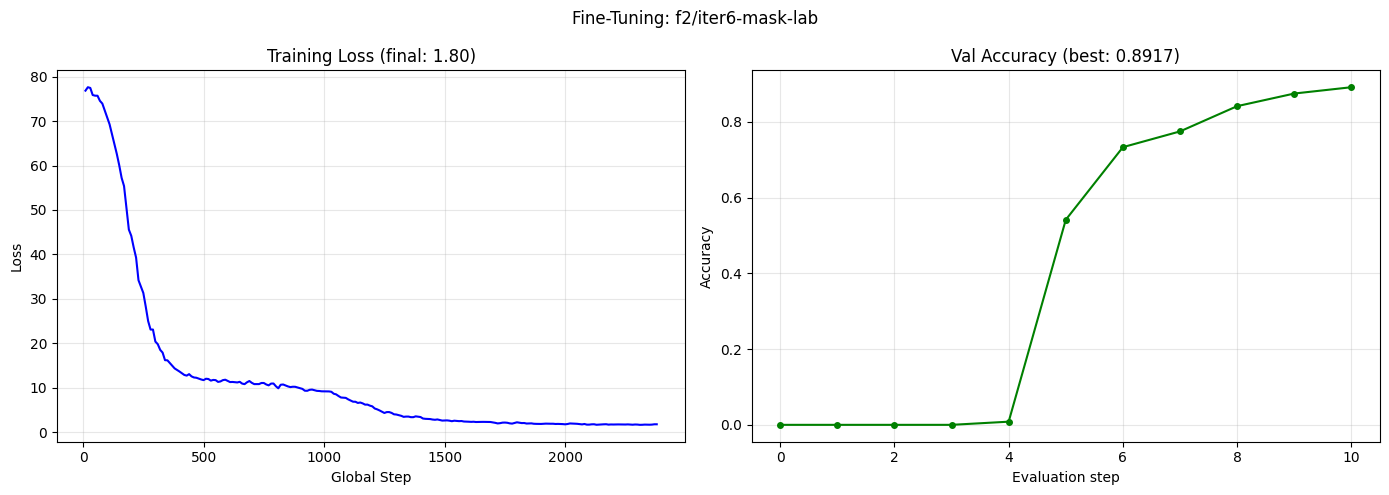


Mejor accuracy (PaddleOCR eval): 0.8917
Ultima accuracy: 0.8917
Mejor norm_edit_dis: 0.9754


In [19]:
# PaddleOCR guarda logs en train_output_dir/train.log
train_log_path = f'{train_output_dir}/train.log'

if os.path.exists(train_log_path):
    # Parsear metricas del log
    train_losses = {}  # step -> loss (dict to deduplicate)
    eval_accs = []
    eval_edit_dists = []

    with open(train_log_path) as f:
        for line in f:
            # Train lines: "... global_step: 10, ... CTCLoss: X, NRTRLoss: Y, loss: Z, ..."
            # Use ", loss:" (with comma) to match only the total loss, not CTCLoss/NRTRLoss
            # Filter out partial-batch lines (avg_samples < 8) to avoid duplicate steps
            if 'global_step' in line and ', loss:' in line:
                try:
                    samples_match = re.search(r'avg_samples:\s*([\d.]+)', line)
                    if samples_match and float(samples_match.group(1)) < 8.0:
                        continue
                    loss_match = re.search(r', loss:\s*([\d.]+)', line)
                    step_match = re.search(r'global_step:\s*(\d+)', line)
                    if loss_match and step_match:
                        train_losses[int(step_match.group(1))] = float(loss_match.group(1))
                except ValueError:
                    pass

            # Eval lines: "cur metric, acc: 0.925, norm_edit_dis: 0.982"
            if 'cur metric' in line:
                try:
                    acc_match = re.search(r'acc:\s*([\d.]+)', line)
                    ned_match = re.search(r'norm_edit_dis:\s*([\d.]+)', line)
                    if acc_match:
                        eval_accs.append(float(acc_match.group(1)))
                    if ned_match:
                        eval_edit_dists.append(float(ned_match.group(1)))
                except ValueError:
                    pass

    # Graficar
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if train_losses:
        steps = sorted(train_losses.keys())
        losses = [train_losses[s] for s in steps]
        axes[0].plot(steps, losses, 'b-', linewidth=1.5)
        axes[0].set_xlabel('Global Step')
        axes[0].set_ylabel('Loss')
        axes[0].set_title(f'Training Loss (final: {losses[-1]:.2f})')
        axes[0].grid(True, alpha=0.3)
    else:
        axes[0].text(0.5, 0.5, 'No train loss data found', ha='center', va='center')

    if eval_accs:
        axes[1].plot(range(len(eval_accs)), eval_accs, 'g-o', markersize=4)
        axes[1].set_xlabel('Evaluation step')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title(f'Val Accuracy (best: {max(eval_accs):.4f})')
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'No eval accuracy data found', ha='center', va='center')

    plt.suptitle(f'Fine-Tuning: {RUN_NAME}', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Resumen numerico
    if eval_accs:
        print(f"\nMejor accuracy (PaddleOCR eval): {max(eval_accs):.4f}")
        print(f"Ultima accuracy: {eval_accs[-1]:.4f}")
    if eval_edit_dists:
        print(f"Mejor norm_edit_dis: {max(eval_edit_dists):.4f}")
else:
    print("No se encontro train.log. Verificar que el entrenamiento se completo.")
    print(f"Buscado en: {train_log_path}")
    print("\nAlternativa: buscar logs en stdout del entrenamiento (celda anterior).")

---

## PARTE 5: EXPORTAR MODELO FINE-TUNED

Convierte `best_accuracy.pdparams` a formato de inferencia (`inference.pdmodel` + `inference.pdiparams`), necesario para usar el modelo con la API `PaddleOCR()`. Los archivos se copian a Drive en la celda 8.1.

In [20]:
# Directorio de inferencia
INFERENCE_DIR = f'{OUTPUT_DIR}/{BASE_MODEL}_infer'

export_cmd = [
    'python3', f'{PADDLEOCR_DIR}/tools/export_model.py',
    '-c', CUSTOM_CONFIG_FILE,
    '-o',
    f'Global.pretrained_model={train_output_dir}/best_accuracy',
    f'Global.character_dict_path={DICT_PATH}',
    f'Global.save_inference_dir={INFERENCE_DIR}',
]

print("Exportando modelo a formato de inferencia...")
result = subprocess.run(
    export_cmd,
    cwd=PADDLEOCR_DIR,
    capture_output=True,
    text=True,
)

if result.returncode == 0:
    print("Modelo exportado exitosamente!")
    print(f"Directorio de inferencia: {INFERENCE_DIR}")
else:
    print("Error al exportar modelo:")
    print(result.stderr[-2000:] if len(result.stderr) > 2000 else result.stderr)

Exportando modelo a formato de inferencia...
Modelo exportado exitosamente!
Directorio de inferencia: /content/ocr-finetune/output/en_PP-OCRv4_mobile_rec_infer


---

## PARTE 6: EVALUACIÓN DEL MODELO FINE-TUNED

### 6.1 Inicializar Motor OCR con Modelo Fine-Tuned

In [21]:
# Evaluar el modelo fine-tuned en modo rec-only
# Usamos paddlex create_model con model_dir apuntando al modelo exportado
if USE_DET:
    print(f'Inicializando PaddleOCR con modelo fine-tuned (det+rec)...')
    ocr_engine = PaddleOCR(
        use_textline_orientation=True,
        lang='en',
        enable_mkldnn=False,
        text_recognition_model_name=BASE_MODEL,
        text_recognition_model_dir=INFERENCE_DIR,
    )
    print(f'Motor OCR inicializado (det+rec, fine-tuned)')
else:
    from paddlex import create_model
    print(f'Inicializando PaddleX rec-only con modelo fine-tuned...')
    ocr_engine = create_model(
        model_name=BASE_MODEL,
        model_dir=INFERENCE_DIR,
    )
    print(f'Motor OCR inicializado (rec-only, fine-tuned)')
    print(f'  Detector:    DESHABILITADO')

print(f'  Modelo rec:  {BASE_MODEL} (fine-tuned)')
print(f'  Inference dir: {INFERENCE_DIR}')


Inicializando PaddleX rec-only con modelo fine-tuned...
Motor OCR inicializado (rec-only, fine-tuned)
  Detector:    DESHABILITADO
  Modelo rec:  en_PP-OCRv4_mobile_rec (fine-tuned)
  Inference dir: /content/ocr-finetune/output/en_PP-OCRv4_mobile_rec_infer


### 6.2 Función de Inferencia OCR

In [22]:
def run_ocr_on_image(ocr_engine, image_path, apply_sanitization=False, use_det=True):
    """Run OCR inference on a single image.

    Supports two modes:
      - use_det=True:  Full pipeline (det+rec) via PaddleOCR.predict()
      - use_det=False: Rec-only via paddlex model.predict()
    """
    if use_det:
        start = time.perf_counter()
        result = ocr_engine.predict(image_path)
        elapsed_ms = (time.perf_counter() - start) * 1000

        texts = []
        confidences = []
        if result:
            for res in result:
                for text, conf in zip(
                    res.get('rec_texts', []), res.get('rec_scores', [])):
                    texts.append(text)
                    confidences.append(conf)
    else:
        import cv2
        img = cv2.imread(image_path)
        if img is None:
            return {
                'raw_text': '', 'digits_text': '', 'prediction': None,
                'confidence': 0.0, 'num_lines': 0, 'time_ms': 0.0,
            }

        texts = []
        confidences = []

        start = time.perf_counter()
        output = ocr_engine.predict(input=img, batch_size=1)

        for res in output:
            rec_text = ''
            rec_score = 0.0
            if hasattr(res, 'json'):
                data = res.json
                if 'res' in data:
                    rec_text = data['res'].get('rec_text', '')
                    rec_score = data['res'].get('rec_score', 0.0)
                else:
                    rec_text = data.get('rec_text', '')
                    rec_score = data.get('rec_score', 0.0)
            elif isinstance(res, dict):
                rec_text = res.get('rec_text', '')
                rec_score = res.get('rec_score', 0.0)
            else:
                rec_text = getattr(res, 'rec_text', '')
                rec_score = getattr(res, 'rec_score', 0.0)
            texts.append(str(rec_text))
            confidences.append(float(rec_score))

        elapsed_ms = (time.perf_counter() - start) * 1000

    raw_text = ''.join(texts) if texts else ''
    digits_text = DIGITS_ONLY_RE.sub('', raw_text)

    if apply_sanitization:
        prediction = sanitize_ocr_output(raw_text)
    else:
        prediction = digits_text if digits_text else None

    avg_conf = sum(confidences) / len(confidences) if confidences else 0.0

    return {
        'raw_text': raw_text,
        'digits_text': digits_text,
        'prediction': prediction,
        'confidence': avg_conf,
        'num_lines': len(texts),
        'time_ms': elapsed_ms,
    }


### 6.3 Ejecutar Evaluación

In [23]:
# Seleccionar el DataFrame de evaluacion
eval_df = val_df.copy() if EVAL_SPLIT == 'val' else test_df.copy()

print(f"Ejecutando evaluacion OCR en {EVAL_SPLIT} set ({len(eval_df)} imagenes)...")
print(f"  Modelo:        {BASE_MODEL} (fine-tuned)")
print(f"  Sanitization:  {USE_SANITIZATION}")
print("=" * 50)

predictions = []
ocr_results = []

for i, (_, row) in enumerate(eval_df.iterrows()):
    img_path = f"{DATASET_PATH}/{row['rel_path']}"

    result = run_ocr_on_image(
        ocr_engine, img_path, apply_sanitization=USE_SANITIZATION,
        use_det=USE_DET)
    predictions.append(result['prediction'])
    ocr_results.append(result)

    if (i + 1) % 30 == 0 or (i + 1) == len(eval_df):
        print(f"  Procesadas {i + 1}/{len(eval_df)} imagenes...")

eval_df['prediction'] = predictions
eval_df['raw_text'] = [r['raw_text'] for r in ocr_results]
eval_df['digits_text'] = [r['digits_text'] for r in ocr_results]
eval_df['confidence'] = [r['confidence'] for r in ocr_results]
eval_df['num_lines'] = [r['num_lines'] for r in ocr_results]
eval_df['time_ms'] = [r['time_ms'] for r in ocr_results]
eval_df['is_correct'] = eval_df['prediction'] == eval_df['label']

avg_time = eval_df['time_ms'].mean()
print(f"\nInferencia completada. Tiempo promedio: {avg_time:.0f} ms/imagen")

Ejecutando evaluacion OCR en val set (120 imagenes)...
  Modelo:        en_PP-OCRv4_mobile_rec (fine-tuned)
  Sanitization:  True
  Procesadas 30/120 imagenes...
  Procesadas 60/120 imagenes...
  Procesadas 90/120 imagenes...
  Procesadas 120/120 imagenes...

Inferencia completada. Tiempo promedio: 17 ms/imagen


---

## PARTE 7: RESULTADOS Y ANÁLISIS

### 7.1 Métricas Globales

In [24]:
metrics = compute_metrics_by_group(eval_df)

print("=" * 60)
print(f"    RESULTADOS: {RUN_NAME} ({EVAL_SPLIT} set)")
print(f"    {RUN_DESCRIPTION}")
print("=" * 60)

for group_name, group_label in [
    ('global', 'Global'),
    ('with_decimal', 'Con decimales'),
    ('without_decimal', 'Sin decimales'),
]:
    if group_name in metrics:
        m = metrics[group_name]
        print(f"\n  --- {group_label} (n={m['total']}) ---")
        print(f"  Exact Match Accuracy:  {m['exact_match']:.4f}  ({m['correct']}/{m['total']})")
        print(f"  CER:                   {m['cer']:.4f}")
        print(f"  CRR (1-CER):           {m['crr']:.4f}")

print("\n" + "=" * 60)

    RESULTADOS: f2/iter6-mask-lab (val set)
    Iter 6: Fine-tuning en_PP-OCRv4_mobile_rec con crops regenerados con la máscara LAB refinada

  --- Global (n=120) ---
  Exact Match Accuracy:  0.8917  (107/120)
  CER:                   0.0262
  CRR (1-CER):           0.9738

  --- Con decimales (n=84) ---
  Exact Match Accuracy:  0.8929  (75/84)
  CER:                   0.0249
  CRR (1-CER):           0.9751

  --- Sin decimales (n=36) ---
  Exact Match Accuracy:  0.8889  (32/36)
  CER:                   0.0287
  CRR (1-CER):           0.9713



### 7.2 Distribución de Confianza

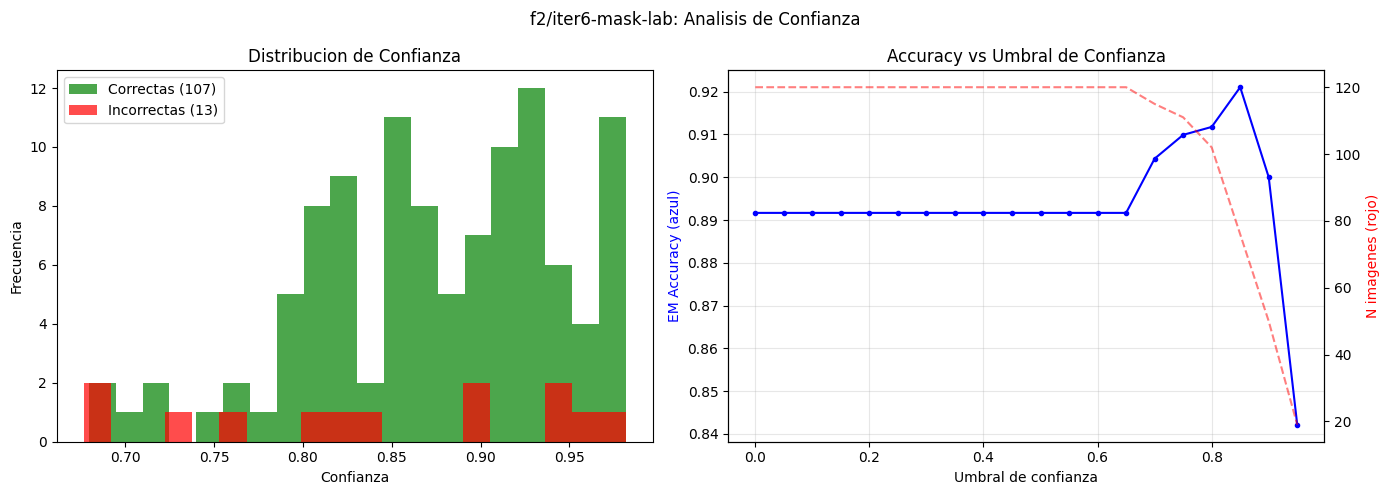

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confianza por correctitud
correct_conf = eval_df[eval_df['is_correct']]['confidence']
incorrect_conf = eval_df[~eval_df['is_correct']]['confidence']

axes[0].hist(correct_conf, bins=20, alpha=0.7, label=f'Correctas ({len(correct_conf)})', color='green')
axes[0].hist(incorrect_conf, bins=20, alpha=0.7, label=f'Incorrectas ({len(incorrect_conf)})', color='red')
axes[0].set_xlabel('Confianza')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribucion de Confianza')
axes[0].legend()

# Confianza vs accuracy por umbral
thresholds = np.arange(0.0, 1.0, 0.05)
accs_at_threshold = []
counts_at_threshold = []
for t in thresholds:
    above = eval_df[eval_df['confidence'] >= t]
    if len(above) > 0:
        accs_at_threshold.append(above['is_correct'].mean())
        counts_at_threshold.append(len(above))
    else:
        accs_at_threshold.append(0)
        counts_at_threshold.append(0)

ax2 = axes[1].twinx()
axes[1].plot(thresholds, accs_at_threshold, 'b-o', markersize=3, label='EM Accuracy')
ax2.plot(thresholds, counts_at_threshold, 'r--', alpha=0.5, label='N imagenes')
axes[1].set_xlabel('Umbral de confianza')
axes[1].set_ylabel('EM Accuracy (azul)', color='blue')
ax2.set_ylabel('N imagenes (rojo)', color='red')
axes[1].set_title('Accuracy vs Umbral de Confianza')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'{RUN_NAME}: Analisis de Confianza', fontsize=12)
plt.tight_layout()
plt.show()

### 7.3 Análisis de Errores

In [26]:
errors_df = eval_df[~eval_df['is_correct']].copy()


def categorize_error(row):
    pred = row['prediction']
    gt = row['label']
    if pred is None:
        return 'no_prediction'
    if len(pred) > len(gt):
        return 'extra_digits'
    if len(pred) < len(gt):
        return 'missing_digits'
    return 'wrong_digits'


errors_df['error_type'] = errors_df.apply(categorize_error, axis=1)

# Resumen
error_counts = errors_df['error_type'].value_counts()
print(f"=== ANALISIS DE ERRORES ({len(errors_df)} errores en {len(eval_df)} imagenes) ===\n")
for error_type, count in error_counts.items():
    pct = count / len(eval_df) * 100
    print(f"  {error_type:20s}: {count:3d}  ({pct:.1f}%)")

# Tabla detallada
print(f"\n{'=' * 90}")
print(f"{'Archivo':12s} {'GT':>10s} {'Prediccion':>12s} {'Raw OCR':>15s} "
      f"{'Conf':>6s} {'Tipo':>15s} {'Decimal':>8s}")
print('-' * 90)
for _, row in errors_df.head(30).iterrows():
    pred_str = row['prediction'] if row['prediction'] is not None else '(None)'
    raw_str = row['raw_text'][:15] if row['raw_text'] else ''
    print(f"{row['filename']:12s} {row['label']:>10s} {pred_str:>12s} "
          f"{raw_str:>15s} {row['confidence']:>6.3f} "
          f"{row['error_type']:>15s} {str(row['has_decimal']):>8s}")

=== ANALISIS DE ERRORES (13 errores en 120 imagenes) ===

  missing_digits      :  11  (9.2%)
  extra_digits        :   1  (0.8%)
  wrong_digits        :   1  (0.8%)

Archivo              GT   Prediccion         Raw OCR   Conf            Tipo  Decimal
------------------------------------------------------------------------------------------
00002.jpg         11649         1649            1649  0.892  missing_digits    False
00056.jpg         01105         0105            0105  0.952  missing_digits     True
00497.jpg          2611          261             261  0.949  missing_digits     True
00507.jpg           005         0005            0005  0.835    extra_digits     True
00755.jpg         00000         0000            0000  0.805  missing_digits     True
00777.jpg         01008         0108            0108  0.737  missing_digits     True
00806.jpg         39614        36914           36914  0.903    wrong_digits    False
01103.jpg         11812         1812            1812  0.951  m

### 7.4 Análisis de Sustituciones por Carácter

In [27]:
substitution_pairs = Counter()
position_errors = Counter()

for _, row in errors_df.iterrows():
    pred = row['prediction']
    gt = row['label']
    if pred is None:
        continue

    min_len = min(len(pred), len(gt))
    for i in range(min_len):
        if pred[i] != gt[i]:
            substitution_pairs[(gt[i], pred[i])] += 1
            position_errors[i] += 1

if substitution_pairs:
    print("=== SUSTITUCIONES MAS COMUNES ===\n")
    for (gt_c, pred_c), count in substitution_pairs.most_common(15):
        print(f"  '{gt_c}' -> '{pred_c}' : {count} veces")
else:
    print("No hay sustituciones para analizar")

if position_errors:
    print(f"\n=== ERRORES POR POSICION ===\n")
    for pos, count in sorted(position_errors.items()):
        print(f"  Posicion {pos}: {count} errores")
else:
    print("No hay errores posicionales para analizar")

=== SUSTITUCIONES MAS COMUNES ===

  '0' -> '5' : 2 veces
  '1' -> '6' : 1 veces
  '6' -> '4' : 1 veces
  '4' -> '9' : 1 veces
  '1' -> '0' : 1 veces
  '5' -> '0' : 1 veces
  '0' -> '8' : 1 veces
  '9' -> '6' : 1 veces
  '6' -> '9' : 1 veces
  '1' -> '8' : 1 veces
  '8' -> '1' : 1 veces
  '1' -> '2' : 1 veces
  '1' -> '5' : 1 veces
  '1' -> '9' : 1 veces

=== ERRORES POR POSICION ===

  Posicion 1: 3 errores
  Posicion 2: 6 errores
  Posicion 3: 6 errores


### 7.5 Predicciones Incorrectas (sample visual)

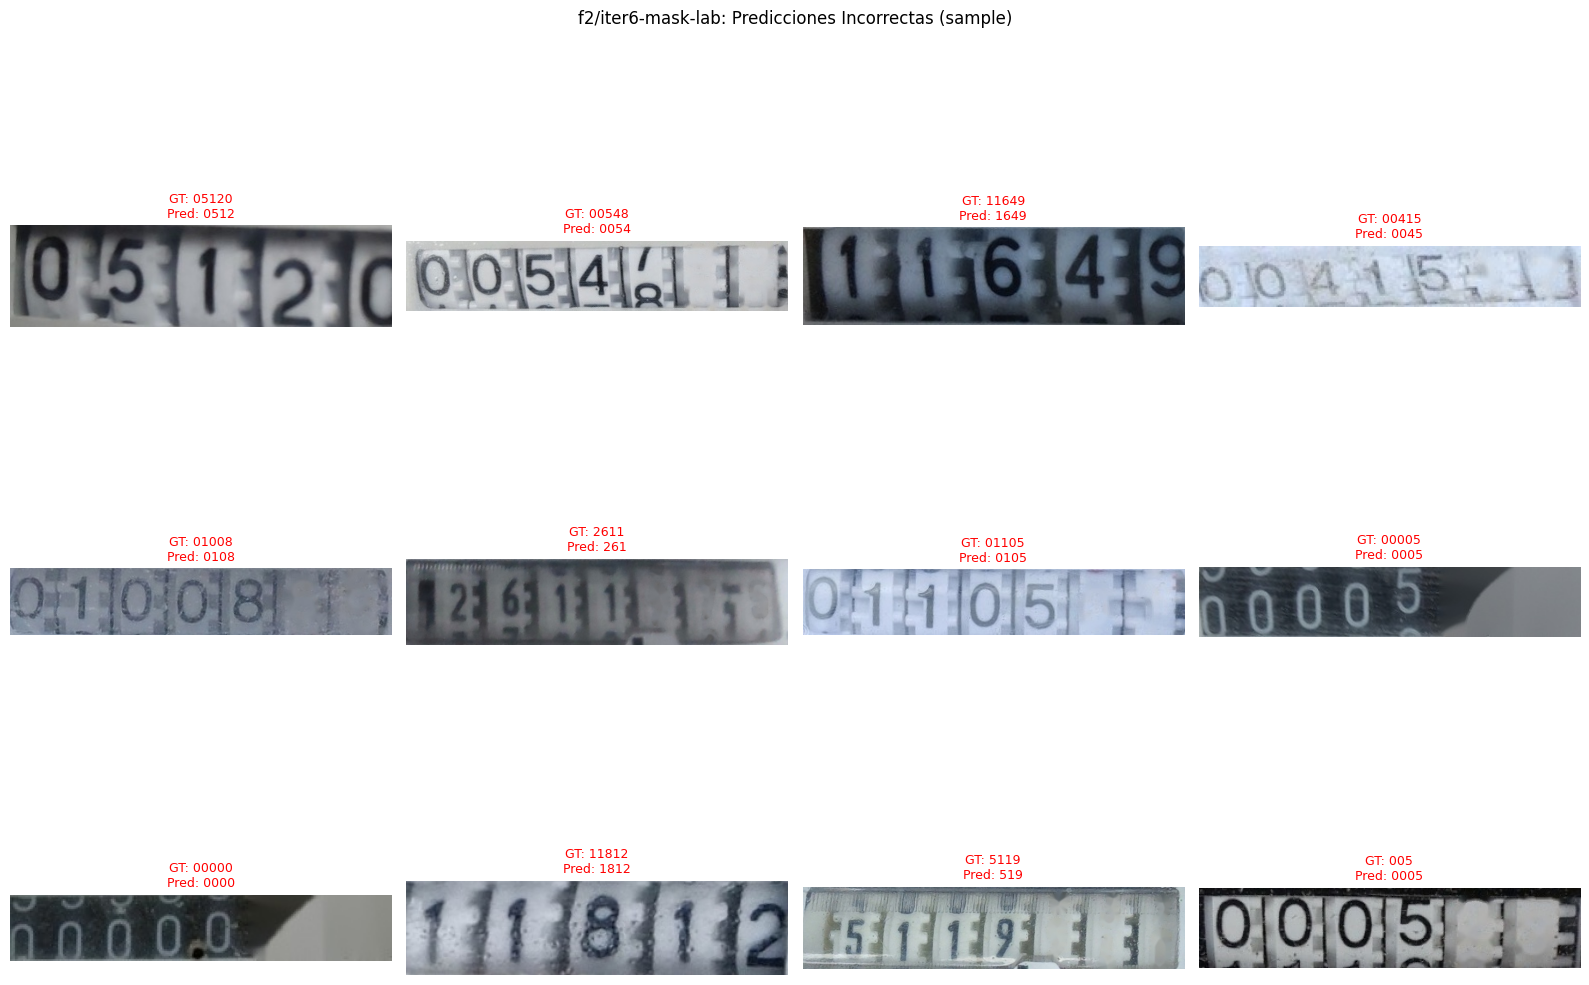

In [28]:
n_show = min(12, len(errors_df))
if n_show > 0:
    sample_errors = (
        errors_df.sample(n=n_show, random_state=42)
        if len(errors_df) > n_show
        else errors_df
    )

    n_cols = 4
    n_rows = (n_show + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for idx, (_, row) in enumerate(sample_errors.iterrows()):
        ax = axes[idx // n_cols][idx % n_cols]
        img_path = f"{DATASET_PATH}/{row['rel_path']}"
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
        pred_str = row['prediction'] if row['prediction'] else '(None)'
        ax.set_title(f"GT: {row['label']}\nPred: {pred_str}", fontsize=9,
                     color='red' if row['prediction'] != row['label'] else 'green')
        ax.axis('off')

    # Ocultar axes vacios
    for idx in range(n_show, n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].axis('off')

    plt.suptitle(f'{RUN_NAME}: Predicciones Incorrectas (sample)', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No hay errores para visualizar (todas las predicciones son correctas).")

### 7.6 Resumen de Rendimiento

In [29]:
m_global = metrics['global']
m_dec = metrics.get('with_decimal', {})
m_nodec = metrics.get('without_decimal', {})

print("\n" + "=" * 60)
print(f"    RESUMEN: {RUN_NAME}")
print(f"    {RUN_DESCRIPTION}")
print("=" * 60)
print(f"\n| {'Metrica':<35} | {'Valor':>10} |")
print("-" * 52)
print(f"| {'Exact Match Accuracy (global) *':<35} | {m_global['exact_match']:>10.4f} |")
print(f"| {'CER (global)':<35} | {m_global['cer']:>10.4f} |")
print(f"| {'CRR (global)':<35} | {m_global['crr']:>10.4f} |")
print("-" * 52)
if m_dec:
    print(f"| {'EM Accuracy (con decimales)':<35} | {m_dec['exact_match']:>10.4f} |")
    print(f"| {'CER (con decimales)':<35} | {m_dec['cer']:>10.4f} |")
if m_nodec:
    print(f"| {'EM Accuracy (sin decimales)':<35} | {m_nodec['exact_match']:>10.4f} |")
    print(f"| {'CER (sin decimales)':<35} | {m_nodec['cer']:>10.4f} |")
print("-" * 52)
print(f"| {'Modelo OCR':<35} | {BASE_MODEL + ' (FT)':>10} |")
print(f"| {'Sanitization':<35} | {str(USE_SANITIZATION):>10} |")
print(f"| {'Split evaluado':<35} | {EVAL_SPLIT:>10} |")
print(f"| {'Imagenes evaluadas':<35} | {len(eval_df):>10} |")
print(f"| {'Tiempo promedio (ms)':<35} | {eval_df['time_ms'].mean():>10.0f} |")
print("=" * 60)
print("* metrica principal")


    RESUMEN: f2/iter6-mask-lab
    Iter 6: Fine-tuning en_PP-OCRv4_mobile_rec con crops regenerados con la máscara LAB refinada

| Metrica                             |      Valor |
----------------------------------------------------
| Exact Match Accuracy (global) *     |     0.8917 |
| CER (global)                        |     0.0262 |
| CRR (global)                        |     0.9738 |
----------------------------------------------------
| EM Accuracy (con decimales)         |     0.8929 |
| CER (con decimales)                 |     0.0249 |
| EM Accuracy (sin decimales)         |     0.8889 |
| CER (sin decimales)                 |     0.0287 |
----------------------------------------------------
| Modelo OCR                          | en_PP-OCRv4_mobile_rec (FT) |
| Sanitization                        |       True |
| Split evaluado                      |        val |
| Imagenes evaluadas                  |        120 |
| Tiempo promedio (ms)                |         17 |
* met

---

## PARTE 8: EXPORTAR RESULTADOS

### 8.1 Exportar Artefactos de la Iteración

Genera `export/{RUN_NAME}/` con modelo + artefactos de evaluación

```
export/{RUN_NAME}/
  model/
    inference.json            ← metadata del modelo (arquitectura)
    inference.pdiparams       ← pesos optimizados para inferencia (PaddleOCR/PaddleX)
    inference.yml             ← config de inferencia PaddleX
    best_accuracy.pdparams    ← pesos de entrenamiento (para fine-tuning adicional)
  results.csv
  eval_config.yaml
  training_config.yaml
  summary.md
```

**Nota:** `inference.*` son los pesos convertidos a formato de inferencia — equivalen a `best.pt` en YOLO. `best_accuracy.pdparams` son los pesos de entrenamiento originales, útiles solo si se requiere fine-tuning adicional sobre este checkpoint.

In [30]:
run_export_dir = f'{EXPORT_DIR}/{RUN_NAME}'
if os.path.exists(run_export_dir):
    shutil.rmtree(run_export_dir)
os.makedirs(run_export_dir, exist_ok=True)

# 1. Copiar modelo de inferencia + best_accuracy.pdparams
model_export_dir = f'{run_export_dir}/model'
shutil.copytree(INFERENCE_DIR, model_export_dir)
if os.path.exists(best_model_path):
    shutil.copy2(best_model_path, model_export_dir)
print("Exportado: model/")

# 2. Exportar CSV de resultados por imagen
results_csv_path = f'{run_export_dir}/results.csv'
export_cols = [
    'filename', 'label', 'prediction', 'raw_text', 'digits_text',
    'confidence', 'num_lines', 'time_ms', 'is_correct', 'has_decimal',
]
eval_df[export_cols].to_csv(results_csv_path, index=False)
print(f"Exportado: results.csv ({len(eval_df)} filas)")

# 3. Exportar eval_config.yaml
eval_config = {
    'run': {
        'name': RUN_NAME,
        'description': RUN_DESCRIPTION,
    },
    'model': {
        'ocr_version': BASE_MODEL,
        'ocr_det_model_name': 'DISABLED (rec-only)' if not USE_DET else 'PP-OCRv5_mobile_det',
        'ocr_model_name': f'{BASE_MODEL} (fine-tuned)',
        'sanitization': USE_SANITIZATION,
        'fine_tuned': True,
        'epochs': FT_EPOCHS,
        'learning_rate': FT_LEARNING_RATE,
        'batch_size': FT_BATCH_SIZE,
        'dictionary': 'digit-only (0-9)',
    },
    'evaluation': {
        'split': EVAL_SPLIT,
        'total_images': int(len(eval_df)),
        'avg_time_ms': round(float(eval_df['time_ms'].mean()), 1),
    },
    'metrics': {},
    'metadata': {
        'exported_on': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    },
}

for group in ['global', 'with_decimal', 'without_decimal']:
    if group in metrics:
        eval_config['metrics'][group] = {
            k: round(float(v), 4) if isinstance(v, float) else v
            for k, v in metrics[group].items()
        }

with open(f'{run_export_dir}/eval_config.yaml', 'w') as f:
    yaml.dump(eval_config, f, default_flow_style=False, sort_keys=False)
print("Exportado: eval_config.yaml")

# 4. Exportar training_config.yaml (especifico de fine-tuning)
training_config = {
    'base_model': BASE_MODEL,
    'config_file': CONFIG_FILE,
    'pretrained_model': PRETRAINED_MODEL,
    'dictionary': 'digit-only (0-9)',
    'epochs': FT_EPOCHS,
    'learning_rate': FT_LEARNING_RATE,
    'batch_size': FT_BATCH_SIZE,
    'warmup_epochs': FT_WARMUP_EPOCHS,
    'max_text_length': FT_MAX_TEXT_LENGTH,
    'eval_batch_step': FT_EVAL_BATCH_STEP,
    'train_images': 959,
    'val_images': 120,
}

with open(f'{run_export_dir}/training_config.yaml', 'w') as f:
    yaml.dump(training_config, f, default_flow_style=False, sort_keys=False)
print("Exportado: training_config.yaml")

# 5. Exportar summary.md
summary_lines = [
    f'# {RUN_NAME} \u2014 Lector OCR (Fine-Tuned)',
    f'> {RUN_DESCRIPTION}',
    '',
    f'- **Fecha**: {datetime.now().strftime("%Y-%m-%d")}',
    f'- **Modelo base**: {BASE_MODEL}',
    f'- **Fine-tuned**: Si (diccionario digit-only)',
    f'- **Epochs**: {FT_EPOCHS}',
    f'- **Learning rate**: {FT_LEARNING_RATE}',
    f'- **Batch size**: {FT_BATCH_SIZE}',
    f'- **Sanitization**: {USE_SANITIZATION}',
    f'- **Split**: {EVAL_SPLIT} ({len(eval_df)} imagenes)',
    f'- **Tiempo promedio**: {eval_df["time_ms"].mean():.0f} ms/imagen',
    '',
    '## Metricas',
    '',
    f'- **Exact Match Accuracy: {metrics["global"]["exact_match"]:.4f}** (principal)',
    f'- CER: {metrics["global"]["cer"]:.4f}',
    f'- CRR: {metrics["global"]["crr"]:.4f}',
]
for group, label in [('with_decimal', 'Con decimales'),
                     ('without_decimal', 'Sin decimales')]:
    if group in metrics:
        m = metrics[group]
        summary_lines += [
            '',
            f'### {label} (n={m["total"]})',
            f'- EM Accuracy: {m["exact_match"]:.4f}',
            f'- CER: {m["cer"]:.4f}',
        ]

with open(f'{run_export_dir}/summary.md', 'w', encoding='utf-8') as f:
    f.write('\n'.join(summary_lines) + '\n')
print("Exportado: summary.md")

# Resumen de archivos exportados
print(f"\n{'=' * 50}")
print(f"EXPORT: {run_export_dir}")
print(f"{'=' * 50}")
for root, dirs, files in os.walk(run_export_dir):
    level = root.replace(run_export_dir, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/" if level > 0 else '')
    for f_name in sorted(files):
        print(f"{'  ' * (level + 1)}{f_name}")

Exportado: model/
Exportado: results.csv (120 filas)
Exportado: eval_config.yaml
Exportado: training_config.yaml
Exportado: summary.md

EXPORT: /content/drive/MyDrive/water-meter-training/ocr-reader/export/f2/iter6-mask-lab

  eval_config.yaml
  results.csv
  summary.md
  training_config.yaml
  model/
    best_accuracy.pdparams
    inference.json
    inference.pdiparams
    inference.yml


---

## PARTE 9: COMPARACIÓN ENTRE ITERACIONES

### 9.1 Comparar con Iteraciones Anteriores

Carga los `eval_config.yaml` de todas las iteraciones exportadas y compara.

In [31]:
# Cargar todas las iteraciones exportadas y comparar (recorre f1/, f2/)
comparison_rows = []

if os.path.exists(EXPORT_DIR):
    for phase in sorted(os.listdir(EXPORT_DIR)):
        phase_dir = f'{EXPORT_DIR}/{phase}'
        if not os.path.isdir(phase_dir):
            continue
        for exp_name in sorted(os.listdir(phase_dir)):
            exp_dir = f'{phase_dir}/{exp_name}'
            full_name = f'{phase}/{exp_name}'
            cfg_path = f'{exp_dir}/eval_config.yaml'
            if os.path.isdir(exp_dir) and os.path.exists(cfg_path):
                with open(cfg_path) as f:
                    cfg = yaml.safe_load(f)

                m = cfg.get('metrics', {}).get('global', {})
                m_dec = cfg.get('metrics', {}).get('with_decimal', {})
                m_nodec = cfg.get('metrics', {}).get('without_decimal', {})

                comparison_rows.append({
                    'Iteracion': full_name,
                    'Modelo': cfg.get('model', {}).get('ocr_version', cfg.get('model', {}).get('ocr_model_name', '?')),
                    'Fine-tuned': cfg.get('model', {}).get('fine_tuned', False),
                    'Sanitization': cfg.get('model', {}).get('sanitization', '?'),
                    'EM Acc (global)': m.get('exact_match', '?'),
                    'CER (global)': m.get('cer', '?'),
                    'EM Acc (dec)': m_dec.get('exact_match', '?'),
                    'EM Acc (nodec)': m_nodec.get('exact_match', '?'),
                })

if comparison_rows:
    comp_df = pd.DataFrame(comparison_rows)
    print('=== COMPARACION ENTRE ITERACIONES ===')
    print()
    print(comp_df.to_string(index=False))
else:
    print('No se encontraron iteraciones exportadas para comparar.')


=== COMPARACION ENTRE ITERACIONES ===

          Iteracion                 Modelo  Fine-tuned  Sanitization  EM Acc (global)  CER (global)  EM Acc (dec)  EM Acc (nodec)
          f1/p0-raw               PP-OCRv5       False          True           0.0083        0.8617        0.0119          0.0000
     f1/p1-mask-hsv               PP-OCRv5       False          True           0.0500        0.8224        0.0714          0.0000
     f1/p2-mask-lab               PP-OCRv5       False          True           0.0417        0.8280        0.0595          0.0000
        f2/baseline               PP-OCRv5       False          True           0.0417        0.8280        0.0595          0.0000
f2/iter1-det-bypass               PP-OCRv5       False          True           0.1583        0.5009        0.1905          0.0833
   f2/iter2-scaling               PP-OCRv5       False          True           0.1333        0.5327        0.1548          0.0833
f2/iter3-v4-english               PP-OCRv4       Fa

### 9.2 Visualizar Progreso de Iteraciones

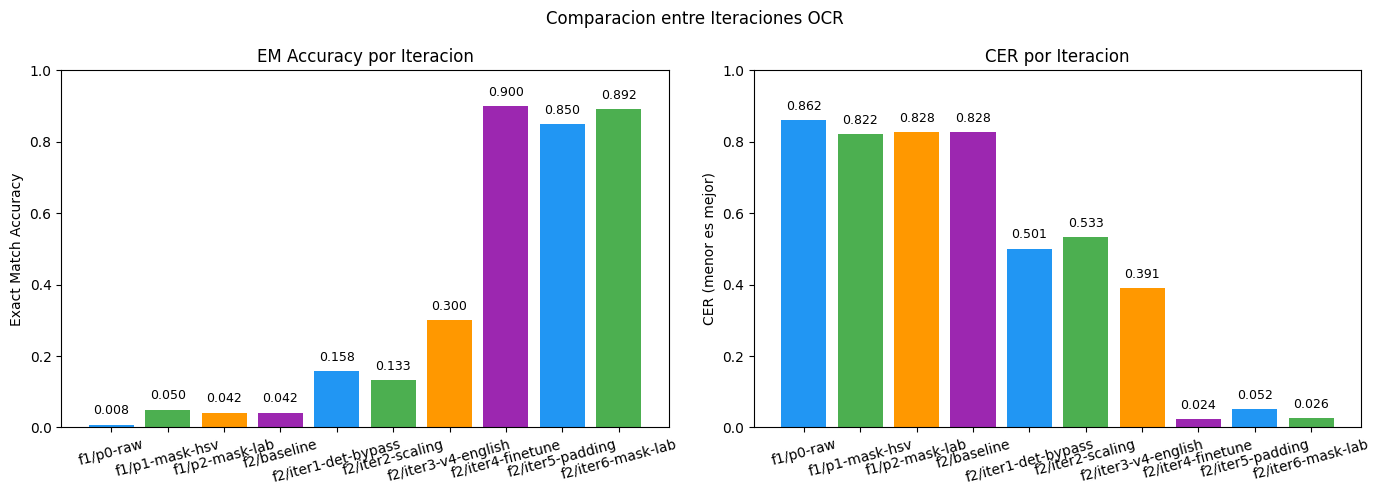

In [32]:
if comparison_rows and len(comparison_rows) > 1:
    comp_df_plot = pd.DataFrame(comparison_rows)
    comp_df_plot['EM Acc (global)'] = pd.to_numeric(
        comp_df_plot['EM Acc (global)'], errors='coerce')
    comp_df_plot['CER (global)'] = pd.to_numeric(
        comp_df_plot['CER (global)'], errors='coerce')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # EM Accuracy por iteracion
    bars = axes[0].bar(
        comp_df_plot['Iteracion'],
        comp_df_plot['EM Acc (global)'],
        color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'][:len(comp_df_plot)],
    )
    axes[0].set_ylabel('Exact Match Accuracy')
    axes[0].set_title('EM Accuracy por Iteracion')
    axes[0].set_ylim(0, 1)
    for bar, val in zip(bars, comp_df_plot['EM Acc (global)']):
        if not pd.isna(val):
            axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                         f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    axes[0].tick_params(axis='x', rotation=15)

    # CER por iteracion
    bars = axes[1].bar(
        comp_df_plot['Iteracion'],
        comp_df_plot['CER (global)'],
        color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'][:len(comp_df_plot)],
    )
    axes[1].set_ylabel('CER (menor es mejor)')
    axes[1].set_title('CER por Iteracion')
    axes[1].set_ylim(0, 1)
    for bar, val in zip(bars, comp_df_plot['CER (global)']):
        if not pd.isna(val):
            axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                         f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    axes[1].tick_params(axis='x', rotation=15)

    plt.suptitle('Comparacion entre Iteraciones OCR', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Se necesitan al menos 2 iteraciones para graficar la comparacion.")

### 9.3 Decisión Greedy

**¿Mejoró el fine-tuning la Exact Match Accuracy?**

- **Sí** → Se mantiene. El modelo fine-tuned es la mejor configuración OCR.
- **No** → Se revierte. Se usa el modelo pretrained de la iteración anterior (Fase 2, Iter 1).

Registrar la decisión en `docs/_final/experiment-results.md`.

---

## PARTE 10: EVALUACIÓN FINAL EN TEST SET

**EJECUTAR SOLO UNA VEZ**, con la configuración ganadora ya fijada.

Si el fine-tuning no mejoró sobre val, usar `04_eval_ocr.ipynb` con la configuración pretrained ganadora para el test final.

### 10.1 Configurar para Test

In [33]:
# =====================================================
# EVALUACION FINAL EN TEST SET
# EJECUTAR SOLO UNA VEZ con la configuracion ganadora
# =====================================================

FINAL_RUN_NAME = 'final-test'
FINAL_EVAL_SPLIT = 'test'

print("ADVERTENCIA: Esta celda evalua en el TEST SET.")
print("Solo ejecutar una vez, con la configuracion ganadora fijada.")
print(f"\n  Run: {FINAL_RUN_NAME}")
print(f"  Split: {FINAL_EVAL_SPLIT}")
print(f"  Modelo: {BASE_MODEL} (fine-tuned)")

ADVERTENCIA: Esta celda evalua en el TEST SET.
Solo ejecutar una vez, con la configuracion ganadora fijada.

  Run: final-test
  Split: test
  Modelo: en_PP-OCRv4_mobile_rec (fine-tuned)


In [34]:
# Ejecutar evaluacion en test set
test_eval_df = test_df.copy()

print(f"Ejecutando evaluacion OCR en test set ({len(test_eval_df)} imagenes)...")
print("=" * 50)

test_predictions = []
test_ocr_results = []

for i, (_, row) in enumerate(test_eval_df.iterrows()):
    img_path = f"{DATASET_PATH}/{row['rel_path']}"

    result = run_ocr_on_image(
        ocr_engine, img_path, apply_sanitization=USE_SANITIZATION,
        use_det=USE_DET)
    test_predictions.append(result['prediction'])
    test_ocr_results.append(result)

    if (i + 1) % 30 == 0 or (i + 1) == len(test_eval_df):
        print(f"  Procesadas {i + 1}/{len(test_eval_df)} imagenes...")

test_eval_df['prediction'] = test_predictions
test_eval_df['raw_text'] = [r['raw_text'] for r in test_ocr_results]
test_eval_df['digits_text'] = [r['digits_text'] for r in test_ocr_results]
test_eval_df['confidence'] = [r['confidence'] for r in test_ocr_results]
test_eval_df['num_lines'] = [r['num_lines'] for r in test_ocr_results]
test_eval_df['time_ms'] = [r['time_ms'] for r in test_ocr_results]
test_eval_df['is_correct'] = test_eval_df['prediction'] == test_eval_df['label']

test_metrics = compute_metrics_by_group(test_eval_df)

print(f"\n{'=' * 60}")
print(f"    RESULTADOS FINALES: TEST SET")
print(f"    Modelo: {BASE_MODEL} (fine-tuned)")
print("=" * 60)

for group_name, group_label in [
    ('global', 'Global'),
    ('with_decimal', 'Con decimales'),
    ('without_decimal', 'Sin decimales'),
]:
    if group_name in test_metrics:
        m = test_metrics[group_name]
        print(f"\n  --- {group_label} (n={m['total']}) ---")
        print(f"  Exact Match Accuracy:  {m['exact_match']:.4f}  ({m['correct']}/{m['total']})")
        print(f"  CER:                   {m['cer']:.4f}")
        print(f"  CRR (1-CER):           {m['crr']:.4f}")

print(f"\n  Tiempo promedio: {test_eval_df['time_ms'].mean():.0f} ms/imagen")
print("=" * 60)

Ejecutando evaluacion OCR en test set (120 imagenes)...
  Procesadas 30/120 imagenes...
  Procesadas 60/120 imagenes...
  Procesadas 90/120 imagenes...
  Procesadas 120/120 imagenes...

    RESULTADOS FINALES: TEST SET
    Modelo: en_PP-OCRv4_mobile_rec (fine-tuned)

  --- Global (n=120) ---
  Exact Match Accuracy:  0.9250  (111/120)
  CER:                   0.0186
  CRR (1-CER):           0.9814

  --- Con decimales (n=84) ---
  Exact Match Accuracy:  0.9405  (79/84)
  CER:                   0.0166
  CRR (1-CER):           0.9834

  --- Sin decimales (n=36) ---
  Exact Match Accuracy:  0.8889  (32/36)
  CER:                   0.0229
  CRR (1-CER):           0.9771

  Tiempo promedio: 9 ms/imagen


In [35]:
# Exportar resultados del test set
test_export_dir = f'{EXPORT_DIR}/{FINAL_RUN_NAME}'
if os.path.exists(test_export_dir):
    shutil.rmtree(test_export_dir)
os.makedirs(test_export_dir)

# CSV de resultados
export_cols = [
    'filename', 'label', 'prediction', 'raw_text', 'digits_text',
    'confidence', 'num_lines', 'time_ms', 'is_correct', 'has_decimal',
]
test_eval_df[export_cols].to_csv(f'{test_export_dir}/results.csv', index=False)

# eval_config.yaml
test_eval_config = {
    'run': {
        'name': FINAL_RUN_NAME,
        'description': f'Evaluacion final en test set: {BASE_MODEL} (fine-tuned)',
    },
    'model': {
        'ocr_version': BASE_MODEL,
        'ocr_model_name': f'{BASE_MODEL} (fine-tuned)',
        'sanitization': USE_SANITIZATION,
        'fine_tuned': True,
    },
    'evaluation': {
        'split': FINAL_EVAL_SPLIT,
        'total_images': int(len(test_eval_df)),
        'avg_time_ms': round(float(test_eval_df['time_ms'].mean()), 1),
    },
    'metrics': {},
    'metadata': {
        'exported_on': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    },
}

for group in ['global', 'with_decimal', 'without_decimal']:
    if group in test_metrics:
        test_eval_config['metrics'][group] = {
            k: round(float(v), 4) if isinstance(v, float) else v
            for k, v in test_metrics[group].items()
        }

with open(f'{test_export_dir}/eval_config.yaml', 'w') as f:
    yaml.dump(test_eval_config, f, default_flow_style=False, sort_keys=False)

# summary.md
summary_lines = [
    f'# {FINAL_RUN_NAME} \u2014 Evaluacion Final OCR (Test Set)',
    f'> Modelo: {BASE_MODEL} (fine-tuned)',
    '',
    f'- **Fecha**: {datetime.now().strftime("%Y-%m-%d")}',
    f'- **Modelo**: {BASE_MODEL} (fine-tuned, diccionario digit-only)',
    f'- **Split**: test ({len(test_eval_df)} imagenes)',
    f'- **Tiempo promedio**: {test_eval_df["time_ms"].mean():.0f} ms/imagen',
    '',
    '## Metricas Finales',
    '',
    f'- **Exact Match Accuracy: {test_metrics["global"]["exact_match"]:.4f}**',
    f'- CER: {test_metrics["global"]["cer"]:.4f}',
    f'- CRR: {test_metrics["global"]["crr"]:.4f}',
]
for group, label in [('with_decimal', 'Con decimales'),
                     ('without_decimal', 'Sin decimales')]:
    if group in test_metrics:
        m = test_metrics[group]
        summary_lines += [
            '',
            f'### {label} (n={m["total"]})',
            f'- EM Accuracy: {m["exact_match"]:.4f}',
            f'- CER: {m["cer"]:.4f}',
        ]

with open(f'{test_export_dir}/summary.md', 'w', encoding='utf-8') as f:
    f.write('\n'.join(summary_lines) + '\n')

print(f"\nResultados del test set exportados en: {test_export_dir}")
for f_name in sorted(os.listdir(test_export_dir)):
    print(f"  {f_name}")


Resultados del test set exportados en: /content/drive/MyDrive/water-meter-training/ocr-reader/export/final-test
  eval_config.yaml
  results.csv
  summary.md


---

## PARTE 11: RESUMEN Y NOTAS

### Notas sobre Fine-Tuning

**Diccionario digit-only:**
- Reduce el espacio de salida de ~95 caracteres ASCII a solo 10 (dígitos 0–9)
- El modelo ya no puede producir letras ni símbolos, eliminando la necesidad del filtro de sanitización para caracteres no numéricos
- La sanitización de longitud (3–8 dígitos) sigue siendo útil

**Separadores entre ruedas:**
- El principal error sistemático del OCR pretrained es leer separadores físicos entre ruedas como dígitos falsos
- Fine-tuning con datos reales de odómetros enseña al modelo qué es un dígito y qué es un separador
- Reglas post-hoc no son suficientes porque el número de dígitos varía entre modelos de medidor

**Dataset pequeño (959 train):**
- Fine-tuning con learning rate bajo y pocos epochs minimiza el riesgo de overfitting
- El backbone PPLCNetV3 (SVTR_LCNet) extrae features robustas; solo ajustamos la capa de reconocimiento al dominio

### Siguiente Paso

Con la mejor configuración OCR fijada (la iteración ganadora), se procede a la **evaluación end-to-end del pipeline completo** (YOLO detector + OCR reader) sobre el test set.

---

## APÉNDICE A: Troubleshooting

### A.1 Si el entrenamiento falla por memoria

Reducir `FT_BATCH_SIZE` (de 4 a 2). Si aún falla, considerar usar `PP-OCRv5_mobile_rec` como alternativa más liviana.

### A.2 Si el entrenamiento no converge

1. Verificar que los labels del dataset son correctos (solo dígitos)
2. Aumentar `FT_EPOCHS` a 30-50
3. Probar con `FT_LEARNING_RATE` más bajo (5e-5)
4. Verificar las curvas de loss — si oscilan, reducir LR

### A.3 Si la sesión de Colab se desconecta

Los checkpoints se guardan en `OUTPUT_DIR` cada epoch. Para reanudar, ver celda A.4.

### A.4 Resumir Entrenamiento desde Checkpoint

In [36]:
# Descomentar para resumir entrenamiento desde el ultimo checkpoint
# NOTA: Solo usar si la sesion se desconecto durante el entrenamiento

# resume_cmd = train_cmd.copy()
# resume_cmd.extend([
#     '-o', f'Global.checkpoints={OUTPUT_DIR}/{BASE_MODEL}/latest',
# ])
#
# print("Resumiendo entrenamiento desde ultimo checkpoint...")
# result = subprocess.run(
#     resume_cmd,
#     cwd=PADDLEOCR_DIR,
#     capture_output=False,
#     text=True,
# )
# print(f"Return code: {result.returncode}")